# RayoScan AI – Dental Tooth Detection (YOLOv8)

#Check GPU

In [2]:
!nvidia-smi
print("GPU active")

Thu Mar 19 03:49:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Install YOLOv8

In [3]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.2 MB/s eta 0:00:00


#Uploading Dataset

In [4]:
from google.colab import files
uploaded = files.upload()
print("Upload complete:", list(uploaded.keys()))

Saving ToothNumber_TaskDataset.zip to ToothNumber_TaskDataset.zip
Upload complete: ['ToothNumber_TaskDataset.zip']


#Extracting Dataset & Auto-generate data.yaml

In [5]:
import zipfile, os, glob
from pathlib import Path

zip_files = glob.glob("*.zip")
assert zip_files, "No zip file found"
zip_path = zip_files[0]
print(f"Found: {zip_path}")

# Extract
os.makedirs("dental_dataset", exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall("dental_dataset")
print("Extracted to dental_dataset/")

# Show structure
for root, dirs, files_list in os.walk("dental_dataset"):
    level = root.replace("dental_dataset", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files_list[:3]:
            print(f"{indent}  {f}")

Found: ToothNumber_TaskDataset.zip
Extracted to dental_dataset/
dental_dataset/
  labels/
    cate7-00074_jpg.rf.12a01f3dc902c5e705afe61f89aa0f44.txt
    cate2-00034_jpg.rf.64636032271eb42f7c9b617ed1b6aac1.txt
    7b27f339-20240914-101612388.txt
  images/
    069750f6-20240914-102814322.jpg
    9e633228-20240730-120302866.jpg
    cate1-00008_jpg.rf.3f73860592a2aef8cf53b9031356ffbb.jpg


In [6]:
import yaml, shutil, random
from pathlib import Path

root = Path("dental_dataset").resolve()

# Check if data.yaml already exists
existing_yamls = list(root.rglob("data.yaml"))

if existing_yamls:
    yaml_path = str(existing_yamls[0])
    print(f"Found existing data.yaml: {yaml_path}")
    with open(yaml_path) as f:
        print(f.read())
else:
    images_dir = root / "images"
    labels_dir = root / "labels"

    # Create train/val split folders
    for split in ["train", "val"]:
        (images_dir / split).mkdir(exist_ok=True)
        (labels_dir / split).mkdir(exist_ok=True)

    # Get all images directly in images/ (not already in train/val)
    all_images = [f for f in images_dir.glob("*") if f.is_file()]
    random.shuffle(all_images)

    split_idx = int(len(all_images) * 0.8)
    train_imgs = all_images[:split_idx]
    val_imgs   = all_images[split_idx:]

    for img in train_imgs:
        shutil.move(str(img), str(images_dir / "train" / img.name))
        lbl = labels_dir / (img.stem + ".txt")
        if lbl.exists():
            shutil.move(str(lbl), str(labels_dir / "train" / lbl.name))

    for img in val_imgs:
        shutil.move(str(img), str(images_dir / "val" / img.name))
        lbl = labels_dir / (img.stem + ".txt")
        if lbl.exists():
            shutil.move(str(lbl), str(labels_dir / "val" / lbl.name))

    print(f"Train: {len(train_imgs)} images | Val: {len(val_imgs)} images")

    # Count classes
    class_ids = set()
    for lf in labels_dir.rglob("*.txt"):
        for line in lf.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                try: class_ids.add(int(parts[0]))
                except: pass
    nc = max(class_ids) + 1 if class_ids else 32
    names = [f"tooth_{i}" for i in range(nc)]

    data = {
        "path": str(root),
        "train": str(images_dir / "train"),
        "val":   str(images_dir / "val"),
        "nc": nc,
        "names": names
    }
    yaml_path = str(root / "data.yaml")
    with open(yaml_path, "w") as f:
        yaml.dump(data, f, default_flow_style=False)

    print(f"Generated data.yaml → {yaml_path}  (nc={nc})")

DATA_YAML = yaml_path
print(f"\nDATA_YAML = {DATA_YAML}")

Train: 397 images | Val: 100 images
Generated data.yaml → /content/dental_dataset/data.yaml  (nc=32)

DATA_YAML = /content/dental_dataset/data.yaml


#Training

In [9]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    project="rayoscan_tooth",
    name="yolov8m_final",
    patience=15,
    optimizer="AdamW",
    lr0=1e-3,
    lrf=1e-2,
    weight_decay=5e-4,
    mosaic=1.0,
    mixup=0.1,
    fliplr=0.5,
    degrees=10.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    save=True,
    exist_ok=True,
    verbose=True,
)

BEST_WEIGHTS = "runs/detect/rayoscan_tooth/yolov8m_final/weights/best.pt"
print(f"Training done {BEST_WEIGHTS}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dental_dataset/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

Validation(check mAP score)

In [10]:
import glob
weights = glob.glob("runs/**/*.pt", recursive=True)
for w in weights:
    print(w)

runs/detect/rayoscan_tooth/yolov8m_final/weights/last.pt
runs/detect/rayoscan_tooth/yolov8m_final/weights/best.pt


In [11]:
BEST_WEIGHTS = "runs/detect/rayoscan_tooth/yolov8m_final/weights/best.pt"
model = YOLO(BEST_WEIGHTS)
metrics = model.val(data=DATA_YAML, imgsz=640, augment=True, verbose=True)
print(f"\nmAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,858,288 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1559.8±856.7 MB/s, size: 72.3 KB)
val: Scanning /content/dental_dataset/labels/val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 46.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6s/it 11.3s
                   all        100       2636      0.712      0.801      0.813      0.533
               tooth_0         88         88       0.73      0.841       0.85       0.56
               tooth_1         88         88        0.8      0.771      0.847       0.53
               tooth_2         96         97      0.702      0.742      0.769      0.469
               tooth_3         95         96      0.699      0.798      0.797      0.501
               tooth_4         86         8

Generate Sample Output Images

  4b0b800d-20240619-131850233.jpg → 36 detections
  cate2-00038_jpg.rf.d2c9b3799254cc04594f41691f96629a.jpg → 34 detections
  c9612b79-20240801-124919207.jpg → 41 detections
  a5c76dbc-20240729-122640382.jpg → 33 detections
  91238e26-20240808-112853454.jpg → 35 detections
  cate2-00027_jpg.rf.cf608bef7b2d8bb65a96dbc4d793ccd7.jpg → 32 detections
  cate8-00382_jpg.rf.6509b2217ce00a598880c341bf23b72f.jpg → 31 detections
  cate6-00069_jpg.rf.f6d5c4f63c0be142252591ef2105a1cb.jpg → 33 detections
  cate4-00091_jpg.rf.a305343401dd3ee09d9cb4f5395fa184.jpg → 32 detections
  cate10-00070_jpg.rf.314fc4568fa0ea36e4854bc770c55005.jpg → 34 detections

🖼️ Preview (first 3):


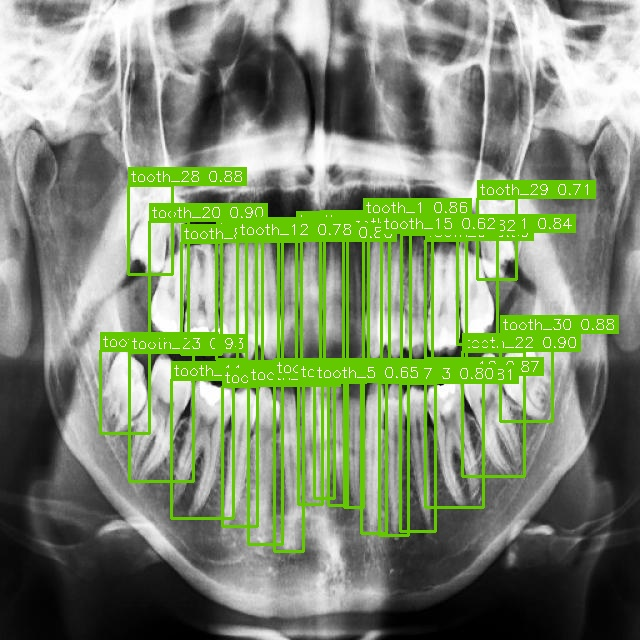

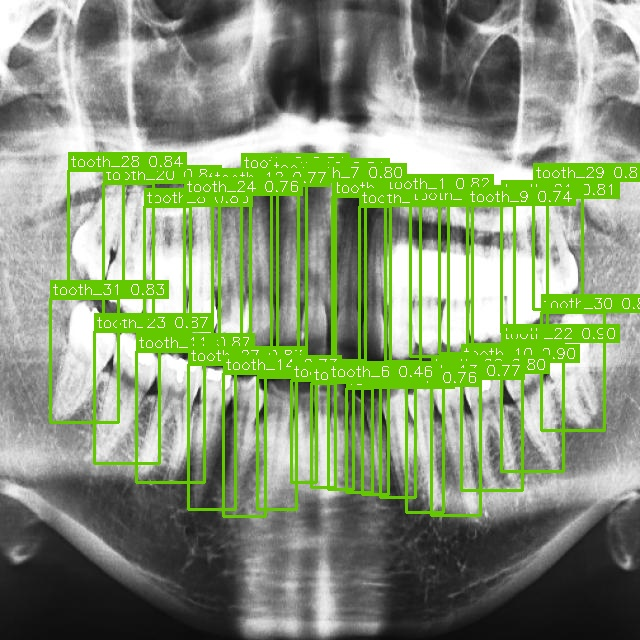

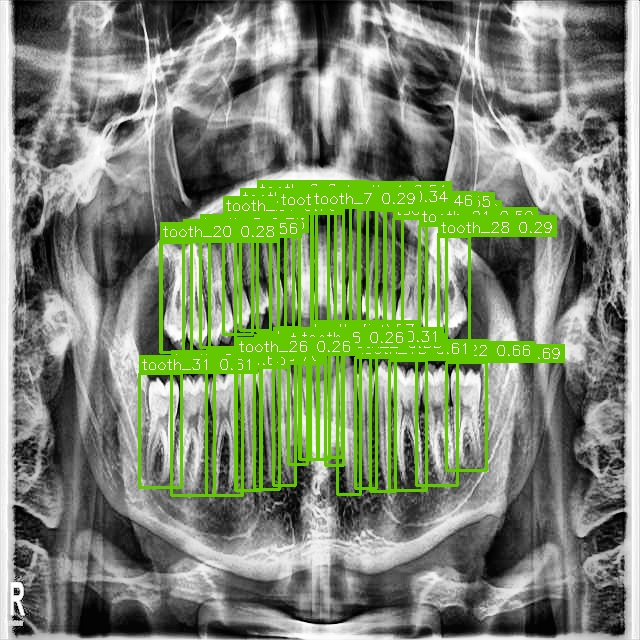

In [12]:
import cv2, random, os
from pathlib import Path
from IPython.display import Image, display

os.makedirs("sample_outputs", exist_ok=True)

# Grab 10 random images
all_imgs = list(Path("dental_dataset").rglob("*.jpg")) + \
           list(Path("dental_dataset").rglob("*.png"))
sample_imgs = random.sample(all_imgs, min(10, len(all_imgs)))

model = YOLO(BEST_WEIGHTS)

for img_path in sample_imgs:
    results = model.predict(str(img_path), conf=0.25, iou=0.45,
                            imgsz=640, verbose=False)
    result = results[0]
    img = cv2.imread(str(img_path))

    for box in result.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0])
        cls  = int(box.cls[0])
        label = f"{result.names[cls]} {conf:.2f}"
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,200,100), 2)
        (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1-th-6), (x1+tw+4, y1), (0,200,100), -1)
        cv2.putText(img, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    out = f"sample_outputs/{img_path.name}"
    cv2.imwrite(out, img)
    print(f"  {img_path.name} → {len(result.boxes)} detections")

# Show first 3 in notebook
print("\n🖼️ Preview (first 3):")
for p in list(Path("sample_outputs").glob("*"))[:3]:
    display(Image(filename=str(p), width=500))

Download as a ZIP

In [14]:
import shutil
from google.colab import files

# Bundle submission folder
os.makedirs("submission", exist_ok=True)

# Copy best weights
os.makedirs("submission/weights", exist_ok=True)
shutil.copy(BEST_WEIGHTS, "submission/weights/best.pt")

# Copy sample outputs
shutil.copytree("sample_outputs", "submission/sample_outputs", dirs_exist_ok=True)

# Write train.py
shutil.copy("/content/train.py", "submission/train.py") if os.path.exists("/content/train.py") else None
shutil.copy("/content/inference.py", "submission/inference.py") if os.path.exists("/content/inference.py") else None

# Zip it all
shutil.make_archive("RayoScan_Submission", "zip", "submission")
files.download("RayoScan_Submission.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Confusion Matrix

In [15]:
from google.colab import files
import os

base = "runs/detect/rayoscan_tooth/yolov8m_final"

for f in ["confusion_matrix.png", "results.png", "val_batch0_pred.jpg"]:
    path = f"{base}/{f}"
    if os.path.exists(path):
        files.download(path)
        print(f"{f}")
    else:
        print(f"not found: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

val_batch0_pred.jpg
